In [ ]:
# FROM HERE ########################################################
#to get the results

In [ ]:
import pretty_midi
import numpy as np
import os
from pathlib import Path

class MIDIPreprocessor:

    def __init__(self, fs=16, window_size=64, pitch_range=(21, 109)):
        self.fs = fs
        self.window_size = window_size
        self.pitch_low = pitch_range[0]
        self.pitch_high = pitch_range[1]
        self.n_pitches = pitch_range[1] - pitch_range[0]

    def load_midi(self, file_path):
        try:
            midi = pretty_midi.PrettyMIDI(file_path)
            return midi
        except Exception as e:
            print(f"Skipping {os.path.basename(file_path)}: {e}")
            return None

    def to_piano_roll(self, midi):
        piano_roll = midi.get_piano_roll(fs=self.fs)

        piano_roll = piano_roll[
            self.pitch_low:self.pitch_high, :
        ]

        piano_roll = (piano_roll > 0).astype(np.float32)

        return piano_roll

    def normalize_timing(self, piano_roll):

        piano_roll = piano_roll.T

        total_steps = piano_roll.shape[0]

        remainder = total_steps % self.window_size

        if remainder != 0:
            piano_roll = piano_roll[:total_steps - remainder, :]

        return piano_roll

    def segment_sequences(self, piano_roll):

        segments = []

        T = piano_roll.shape[0]

        for start in range(
            0,
            T - self.window_size + 1,
            self.window_size
        ):

            segment = piano_roll[
                start:start + self.window_size
            ]

            segments.append(segment)

        return np.array(segments)

    def process_file(self, file_path):

        midi = self.load_midi(file_path)

        if midi is None:
            return None

        piano_roll = self.to_piano_roll(midi)

        piano_roll = self.normalize_timing(
            piano_roll
        )

        segments = self.segment_sequences(
            piano_roll
        )

        return segments

    def process_folder(
        self,
        folder_path,
        max_files=None
    ):

        all_segments = []

        files = sorted(
            Path(folder_path).glob("*.midi")
        )

        if max_files:
            files = files[:max_files]

        print(
            f"Processing {len(files)} files from: {folder_path}"
        )

        for i, file_path in enumerate(files):

            segments = self.process_file(
                str(file_path)
            )

            if (
                segments is not None
                and len(segments) > 0
            ):
                all_segments.append(segments)

            if (i + 1) % 100 == 0:
                print(
                    f"{i+1}/{len(files)} files done..."
                )

        result = np.concatenate(
            all_segments,
            axis=0
        )

        print(f"Done! Shape: {result.shape}")

        return result

print("✅ MIDIPreprocessor defined!")

✅ MIDIPreprocessor defined!


In [ ]:
# Run preprocessing

processor = MIDIPreprocessor(
    fs=16,
    window_size=64
)

train_data = processor.process_folder(
    "data/processed/train/"
)

test_data = processor.process_folder(
    "data/processed/test/"
)

import os
os.makedirs("/kaggle/working/numpy/", exist_ok=True)

np.save(
    "/kaggle/working/numpy/train_data.npy",
    train_data
)

np.save(
    "/kaggle/working/numpy/test_data.npy",
    test_data
)

print("✅ Saved successfully!")
print(train_data.shape)
print(test_data.shape)

Processing 962 files from: data/processed/train/
100/962 files done...
200/962 files done...
300/962 files done...
400/962 files done...
500/962 files done...
600/962 files done...
700/962 files done...
800/962 files done...
900/962 files done...
Done! Shape: (143037, 64, 88)
Processing 177 files from: data/processed/test/
100/177 files done...
Done! Shape: (17948, 64, 88)
✅ Saved successfully!
(143037, 64, 88)
(17948, 64, 88)


In [ ]:
train_data = np.load("/kaggle/working/numpy/train_data.npy")

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

train_data = np.load("/kaggle/working/numpy/train_data.npy")
test_data  = np.load("/kaggle/working/numpy/test_data.npy")

print(train_data.shape)
print(test_data.shape)

X_train = torch.FloatTensor(train_data)
X_test  = torch.FloatTensor(test_data)

train_loader = DataLoader(
    TensorDataset(X_train),
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test),
    batch_size=128,
    shuffle=False
)

print("✅ DataLoaders ready!")

(143037, 64, 88)
(17948, 64, 88)
✅ DataLoaders ready!


In [ ]:
!cat src/models/LSTM_encoder.py

import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import pickle
import numpy as np


class LSTMEncoder(nn.Module):
    def __init__(self, input_size=88, hidden_size=256, num_layers=2, 
                latent_dim=64, dropout=0.2, bidirectional=True):
        super(LSTMEncoder, self).__init__()
        
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.latent_dim = latent_dim
        self.bidirectional = bidirectional

        self.lstm_output_dim = hidden_size * 2 if bidirectional else hidden_size

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        self.fc1 = nn.Linear(self.lstm_output_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, la

In [ ]:
import sys
sys.path.insert(0, '/kaggle/working/Generating_musics')

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import pickle
import numpy as np


class LSTMEncoder(nn.Module):
    def __init__(self, input_size=88, hidden_size=256, num_layers=2,
                latent_dim=64, dropout=0.2, bidirectional=True):
        super(LSTMEncoder, self).__init__()

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.latent_dim = latent_dim
        self.bidirectional = bidirectional

        self.lstm_output_dim = hidden_size * 2 if bidirectional else hidden_size

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )

        self.fc1 = nn.Linear(self.lstm_output_dim, hidden_size)
        self.fc2 = nn.Linear(hidden_size, latent_dim)

        self.bn1 = nn.BatchNorm1d(hidden_size)
        self.bn2 = nn.BatchNorm1d(latent_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        batch_size = x.size(0)

        lstm_out, (hidden, cell) = self.lstm(x)
        last_out = lstm_out[:, -1, :]

        x = self.fc1(last_out)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.bn2(x)

        latent = x

        return latent, (hidden, cell)

    def encode_sequence(self, x):
        latent, _ = self.forward(x)
        return latent


class LSTMDecoder(nn.Module):

    def __init__(self, latent_dim=64, hidden_size=256, num_layers=2,
                output_size=88, seq_len=64, dropout=0.2):

        super(LSTMDecoder, self).__init__()

        self.latent_dim = latent_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_size = output_size
        self.seq_len = seq_len

        self.latent_to_hidden = nn.Linear(latent_dim, hidden_size * num_layers)
        self.latent_to_cell = nn.Linear(latent_dim, hidden_size * num_layers)

        self.lstm = nn.LSTM(
            input_size=output_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc_out = nn.Linear(hidden_size, output_size)

        self.dropout = nn.Dropout(dropout)

    def forward(self, latent, teacher_forcing_ratio=0.0, target=None):
        batch_size = latent.size(0)
        device = latent.device

        hidden = self.latent_to_hidden(latent).view(
            self.num_layers, batch_size, self.hidden_size
        )
        cell = self.latent_to_cell(latent).view(
            self.num_layers, batch_size, self.hidden_size
        )

        if target is not None and torch.rand(1).item() > teacher_forcing_ratio:
            input_t = target[:, 0, :]  # Use first timestep of target
        else:
            input_t = torch.zeros(batch_size, self.output_size, device=device)

        outputs = []

        for t in range(self.seq_len):
            lstm_out, (hidden, cell) = self.lstm(
                input_t.unsqueeze(1), (hidden, cell)
            )

            output = self.fc_out(lstm_out.squeeze(1))
            output = torch.sigmoid(output)  # Binary piano roll
            outputs.append(output)

            if target is not None and torch.rand(1).item() > teacher_forcing_ratio:
                input_t = target[:, t, :]
            else:
                input_t = output

        outputs = torch.stack(outputs, dim=1)  # (batch_size, seq_len, output_size)
        return outputs


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size=88, hidden_size=256, num_layers=2,
                latent_dim=64, seq_len=64, dropout=0.2, bidirectional=True):
        super(LSTMAutoencoder, self).__init__()

        self.encoder = LSTMEncoder(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            latent_dim=latent_dim,
            dropout=dropout,
            bidirectional=bidirectional
        )

        self.decoder = LSTMDecoder(
            latent_dim=latent_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            output_size=input_size,
            seq_len=seq_len,
            dropout=dropout
        )

    def forward(self, x, teacher_forcing_ratio=0.0):
        latent, _ = self.encoder(x)
        reconstructed = self.decoder(latent, teacher_forcing_ratio, target=x)
        return reconstructed, latent


def load_preprocessed_data(data_dir='data/preprocessed_output/sequences/train',
                        max_files=None):

    data_path = Path(data_dir)
    pkl_files = sorted(list(data_path.glob('*.pkl')))

    if max_files:
        pkl_files = pkl_files[:max_files]

    print(f"Loading {len(pkl_files)} files from {data_dir}...")

    all_segments = []
    for i, pkl_file in enumerate(pkl_files):
        with open(pkl_file, 'rb') as f:
            segments = pickle.load(f)
            all_segments.append(segments)

        if (i + 1) % 100 == 0:
            print(f"  Loaded {i+1}/{len(pkl_files)} files...")

    # Concatenate all segments
    dataset = np.concatenate(all_segments, axis=0)
    print(f"✓ Loaded dataset shape: {dataset.shape}")

    return dataset


class MIDIDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir='data/preprocessed_output/sequences/train',
                max_files=None):
        self.data = load_preprocessed_data(data_dir, max_files)
        self.data = torch.FloatTensor(self.data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


def test_model():
    print("Testing LSTM Encoder...")
    batch_size = 4
    seq_len = 64
    n_pitches = 88

    dummy_input = torch.randn(batch_size, seq_len, n_pitches)

    # Test encoder
    encoder = LSTMEncoder(input_size=88, latent_dim=64)
    latent, (hidden, cell) = encoder(dummy_input)
    print(f"  Input shape: {dummy_input.shape}")
    print(f"  Latent shape: {latent.shape}")

    # Test decoder
    decoder = LSTMDecoder(latent_dim=64, output_size=88, seq_len=64)
    reconstructed = decoder(latent)
    print(f"  Reconstructed shape: {reconstructed.shape}")

    # Test autoencoder
    autoencoder = LSTMAutoencoder(input_size=88, latent_dim=64)
    recon, latent_out = autoencoder(dummy_input)
    print(f"  Autoencoder output shape: {recon.shape}")
    print(f"  Latent shape: {latent_out.shape}")

    print("\n✓ All tests passed!")


if __name__ == "__main__":
    test_model()

Testing LSTM Encoder...
  Input shape: torch.Size([4, 64, 88])
  Latent shape: torch.Size([4, 64])
  Reconstructed shape: torch.Size([4, 64, 88])
  Autoencoder output shape: torch.Size([4, 64, 88])
  Latent shape: torch.Size([4, 64])

✓ All tests passed!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = LSTMAutoencoder(
    input_size=88,
    hidden_size=256,
    num_layers=2,
    latent_dim=64,
    seq_len=64,
    dropout=0.2,
    bidirectional=True
).to(device)

print("✅ Model created!")

cuda
✅ Model created!


In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset

train_data = np.load("/kaggle/working/numpy/train_data.npy")
test_data  = np.load("/kaggle/working/numpy/test_data.npy")

print(train_data.shape)
print(test_data.shape)

X_train = torch.FloatTensor(train_data)
X_test  = torch.FloatTensor(test_data)

train_loader = DataLoader(
    TensorDataset(X_train),
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test),
    batch_size=128,
    shuffle=False
)

print("✅ Dataloaders ready!")

(143037, 64, 88)
(17948, 64, 88)
✅ Dataloaders ready!


In [ ]:
import torch.optim as optim
import torch.nn as nn

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

print("✅ Optimizer and loss ready!")

✅ Optimizer and loss ready!


In [ ]:
EPOCHS = 10

train_losses = []
test_losses = []

for epoch in range(EPOCHS):

    # ===== TRAIN =====
    model.train()
    batch_losses = []

    for batch in train_loader:

        x = batch[0].to(device)

        optimizer.zero_grad()

        reconstructed, latent = model(
            x,
            teacher_forcing_ratio=0.5
        )

        loss = criterion(reconstructed, x)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)

    # ===== TEST =====
    model.eval()
    batch_losses = []

    with torch.no_grad():

        for batch in test_loader:

            x = batch[0].to(device)

            reconstructed, latent = model(
                x,
                teacher_forcing_ratio=0.0
            )

            loss = criterion(reconstructed, x)

            batch_losses.append(loss.item())

    test_loss = np.mean(batch_losses)
    test_losses.append(test_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f}"
    )

Epoch 1/10 | Train Loss: 0.1881 | Test Loss: 0.1659
Epoch 2/10 | Train Loss: 0.1630 | Test Loss: 0.1418
Epoch 3/10 | Train Loss: 0.1278 | Test Loss: 0.0948
Epoch 4/10 | Train Loss: 0.1012 | Test Loss: 0.0770
Epoch 5/10 | Train Loss: 0.0883 | Test Loss: 0.0630
Epoch 6/10 | Train Loss: 0.0780 | Test Loss: 0.0541
Epoch 7/10 | Train Loss: 0.0716 | Test Loss: 0.0488
Epoch 8/10 | Train Loss: 0.0673 | Test Loss: 0.0457
Epoch 9/10 | Train Loss: 0.0643 | Test Loss: 0.0436
Epoch 10/10 | Train Loss: 0.0619 | Test Loss: 0.0424


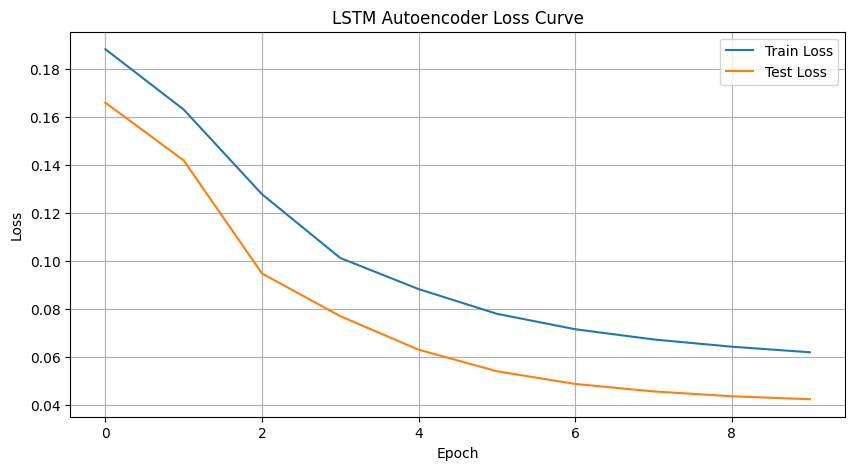

✅ Loss curve saved!


In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("/kaggle/working/outputs/plots", exist_ok=True)

plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Autoencoder Loss Curve")

plt.legend()
plt.grid(True)

plt.savefig("/kaggle/working/outputs/plots/loss_curve.png")

plt.show()

print("✅ Loss curve saved!")

In [ ]:
os.makedirs("/kaggle/working/outputs/models", exist_ok=True)

torch.save(
    model.state_dict(),
    "/kaggle/working/outputs/models/lstm_autoencoder.pth"
)

print("✅ Model saved!")

✅ Model saved!


In [ ]:
model = LSTMAutoencoder(
    input_size=88,
    hidden_size=256,
    num_layers=2,
    latent_dim=64,
    seq_len=64,
    dropout=0.2,
    bidirectional=True
).to(device)

model.load_state_dict(torch.load(
    "/kaggle/working/outputs/models/lstm_autoencoder.pth",
    map_location=device
))

model.eval()

print("✅ Model loaded successfully!")

✅ Model loaded successfully!


In [ ]:
import torch.nn as nn

criterion = nn.BCELoss()

losses = []

with torch.no_grad():
    for batch in test_loader:
        x = batch[0].to(device)
        xhat, _ = model(x)
        loss = criterion(xhat, x)
        losses.append(loss.item())

task1_loss = np.mean(losses)
print("Task 1 Loss:", task1_loss)

Task 1 Loss: 0.042404415046281


In [ ]:
def rhythm_diversity(batch):
    return len(np.unique(batch)) / batch.size

sample = train_data[:1000]
drhythm_task1 = rhythm_diversity(sample)
print("Rhythm Diversity:", drhythm_task1)

Rhythm Diversity: 3.5511363636363634e-07


In [ ]:
class MusicVAE(nn.Module):
    def __init__(self, input_size=88, hidden_size=256, latent_dim=64, num_layers=2):
        super(MusicVAE, self).__init__()

        self.num_layers   = num_layers
        self.hidden_size  = hidden_size
        self.latent_dim   = latent_dim

        # Bidirectional LSTM encoder — reads sequence forward and backward
        self.encoder_lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = 0.3,
            bidirectional = True
        )
        self.fc_mu     = nn.Linear(hidden_size * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size * 2, latent_dim)

        # Autoregressive LSTM decoder
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_size * num_layers)
        self.latent_to_cell   = nn.Linear(latent_dim, hidden_size * num_layers)
        self.decoder_lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = 0.3
        )
        self.fc_out  = nn.Linear(hidden_size, input_size)
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        _, (hidden, _) = self.encoder_lstm(x)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        mu     = self.fc_mu(hidden)
        logvar = torch.clamp(self.fc_logvar(hidden), min=-4.0, max=4.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, seq_len=64):
        batch_size = z.size(0)
        hidden = self.latent_to_hidden(z).view(self.num_layers, batch_size, self.hidden_size)
        cell   = self.latent_to_cell(z).view(self.num_layers, batch_size, self.hidden_size)
        x      = torch.zeros(batch_size, 1, 88).to(z.device)
        outputs = []
        for _ in range(seq_len):
            out, (hidden, cell) = self.decoder_lstm(x, (hidden, cell))
            out = self.sigmoid(self.fc_out(out))
            outputs.append(out)
            x = out
        return torch.cat(outputs, dim=1)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        xhat       = self.decode(z, seq_len=x.size(1))
        return xhat, mu, logvar


def vae_loss(xhat, x, mu, logvar, beta=1.0):
    """
    Standard VAE loss — no free bits this time.
    Reconstruction dominates early (beta small), KL enforced later.
    """
    recon = nn.BCELoss()(xhat, x)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl

print("✅ MusicVAE defined!")

✅ MusicVAE defined!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def focal_loss(logits, targets, gamma=2.0, pos_weight=20.0):
    """
    Focal Loss — fixes the 97-98% sparsity problem in piano rolls.

    Why BCE fails:
        Piano rolls are ~98% zeros. BCE lets the model cheat by predicting
        near-zero everywhere — it gets low loss without learning any notes.

    How Focal Loss fixes it:
        - pos_weight=20.0 means active notes (1s) count 20x more than silence
        - gamma=2.0 reduces gradient from easy examples (correctly predicted 0s)
        - Forces the model to actually learn note patterns
    """
    # Compute BCE with logits (numerically stable — no double sigmoid)
    bce = F.binary_cross_entropy_with_logits(
        logits, targets,
        pos_weight=torch.tensor(pos_weight).to(logits.device),
        reduction='none'
    )
    # Focal modulation: down-weight easy examples
    probs = torch.sigmoid(logits)
    pt    = torch.where(targets == 1, probs, 1 - probs)
    focal = ((1 - pt) ** gamma) * bce
    return focal.mean()


class MusicVAE(nn.Module):
    def __init__(self, input_size=88, hidden_size=256, latent_dim=64, num_layers=2):
        super(MusicVAE, self).__init__()

        self.num_layers  = num_layers
        self.hidden_size = hidden_size
        self.latent_dim  = latent_dim

        # Bidirectional LSTM encoder
        self.encoder_lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = 0.3,
            bidirectional = True
        )
        self.fc_mu     = nn.Linear(hidden_size * 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_size * 2, latent_dim)

        # Autoregressive LSTM decoder
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_size * num_layers)
        self.latent_to_cell   = nn.Linear(latent_dim, hidden_size * num_layers)
        self.decoder_lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = 0.3
        )
        # NO sigmoid here — output raw logits for Focal Loss
        self.fc_out = nn.Linear(hidden_size, input_size)

    def encode(self, x):
        _, (hidden, _) = self.encoder_lstm(x)
        hidden = torch.cat([hidden[-2], hidden[-1]], dim=1)
        mu     = self.fc_mu(hidden)
        logvar = torch.clamp(self.fc_logvar(hidden), min=-4.0, max=4.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode_autoregressive(self, z, seq_len=64):
        """
        Used ONLY at generation time.
        Generates step by step — each output fed as next input.
        Returns probabilities (sigmoid applied here, not during training).
        """
        batch_size = z.size(0)
        hidden = self.latent_to_hidden(z).view(self.num_layers, batch_size, self.hidden_size)
        cell   = self.latent_to_cell(z).view(self.num_layers, batch_size, self.hidden_size)

        x = torch.zeros(batch_size, 1, 88).to(z.device)
        outputs = []
        for _ in range(seq_len):
            out, (hidden, cell) = self.decoder_lstm(x, (hidden, cell))
            logit = self.fc_out(out)           # raw logit
            prob  = torch.sigmoid(logit)       # probability for next input
            outputs.append(prob)
            x = prob
        return torch.cat(outputs, dim=1)       # [batch, seq_len, 88]

    def forward(self, x):
        """
        Used during training.
        Returns raw logits (no sigmoid) — Focal Loss handles sigmoid internally.
        """
        mu, logvar = self.encode(x)
        z          = self.reparameterize(mu, logvar)
        hidden = self.latent_to_hidden(z).view(self.num_layers, x.size(0), self.hidden_size)
        cell   = self.latent_to_cell(z).view(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.decoder_lstm(x, (hidden, cell))
        logits = self.fc_out(out)              # raw logits — NO sigmoid
        return logits, mu, logvar


def vae_loss(logits, x, mu, logvar, beta=1.0):
    recon = focal_loss(logits, x, gamma=2.0, pos_weight=20.0)
    kl    = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon, kl

print("✅ MusicVAE with Focal Loss defined!")

✅ MusicVAE with Focal Loss defined!


In [ ]:
EPOCHS       = 10
train_losses = []
test_losses  = []
kl_losses    = []

model_vae = MusicVAE().to(device)
optimizer  = optim.Adam(model_vae.parameters(), lr=1e-3)

os.makedirs("/kaggle/working/checkpoints/vae/", exist_ok=True)

for epoch in range(EPOCHS):
    # Beta=0 for first 5 epochs — pure reconstruction first
    # Then ramp up to 0.5 gradually
    beta = 0.0 if epoch < 5 else min(0.5, (epoch - 5) * 0.05)

    model_vae.train()
    b_train, b_kl = [], []
    for batch in train_loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        logits, mu, logvar   = model_vae(x)
        loss, recon, kl      = vae_loss(logits, x, mu, logvar, beta=beta)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_vae.parameters(), 1.0)
        optimizer.step()
        b_train.append(recon.item())
        b_kl.append(kl.item())

    model_vae.eval()
    b_test = []
    with torch.no_grad():
        for batch in test_loader:
            x = batch[0].to(device)
            logits, mu, logvar = model_vae(x)
            _, recon, _        = vae_loss(logits, x, mu, logvar, beta=beta)
            b_test.append(recon.item())

    tl = np.mean(b_train)
    vl = np.mean(b_test)
    kl = np.mean(b_kl)
    train_losses.append(tl)
    test_losses.append(vl)
    kl_losses.append(kl)

    print(f"Epoch [{epoch+1:2d}/{EPOCHS}]  "
          f"Train: {tl:.4f}  Test: {vl:.4f}  "
          f"KL: {kl:.4f}  Beta: {beta:.2f}")

    torch.save({
        'epoch'       : epoch + 1,
        'model_state' : model_vae.state_dict(),
        'train_losses': train_losses,
        'test_losses' : test_losses,
        'kl_losses'   : kl_losses
    }, f"/kaggle/working/checkpoints/vae/vae_epoch_{epoch+1}.pth")
    print(f"  💾 Checkpoint saved!")

Epoch [ 1/10]  Train: 0.0257  Test: 0.0008  KL: 1.6299  Beta: 0.00
  💾 Checkpoint saved!
Epoch [ 2/10]  Train: 0.0009  Test: 0.0002  KL: 1.6061  Beta: 0.00
  💾 Checkpoint saved!
Epoch [ 3/10]  Train: 0.0004  Test: 0.0001  KL: 1.5700  Beta: 0.00
  💾 Checkpoint saved!
Epoch [ 4/10]  Train: 0.0002  Test: 0.0000  KL: 1.5459  Beta: 0.00
  💾 Checkpoint saved!
Epoch [ 5/10]  Train: 0.0003  Test: 0.0000  KL: 1.5292  Beta: 0.00
  💾 Checkpoint saved!
Epoch [ 6/10]  Train: 0.0001  Test: 0.0000  KL: 1.5212  Beta: 0.00
  💾 Checkpoint saved!
Epoch [ 7/10]  Train: 0.0003  Test: 0.0000  KL: 0.0103  Beta: 0.05
  💾 Checkpoint saved!
Epoch [ 8/10]  Train: 0.0003  Test: 0.0000  KL: 0.0000  Beta: 0.10
  💾 Checkpoint saved!
Epoch [ 9/10]  Train: 0.0001  Test: 0.0000  KL: 0.0000  Beta: 0.15
  💾 Checkpoint saved!
Epoch [10/10]  Train: 0.0001  Test: 0.0001  KL: 0.0000  Beta: 0.20
  💾 Checkpoint saved!


In [ ]:
vae_losses = []

model_vae.eval()

with torch.no_grad():
    for batch in test_loader:
        x = batch[0].to(device)
        logits, mu, logvar = model_vae(x)
        loss, recon, kl = vae_loss(logits, x, mu, logvar, beta=0.5)
        vae_losses.append(loss.item())

task2_loss = np.mean(vae_losses)
print("Task 2 Loss:", task2_loss)

Task 2 Loss: 8.978416435832302e-05


In [ ]:
kl_vals = []

with torch.no_grad():
    for batch in test_loader:
        x = batch[0].to(device)
        _, mu, logvar = model_vae(x)
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        kl_vals.append(kl.item())

task2_kl = np.mean(kl_vals)
print("Task 2 KL:", task2_kl)

Task 2 KL: 4.120165893719457e-06


In [ ]:
with torch.no_grad():
    sample = model_vae.decode_autoregressive(
        torch.randn(1, 64).to(device),
        seq_len=64
    )

sample = sample.detach().cpu().numpy()

# Rhythm diversity (binary threshold for meaningful metric)
sample_bin = (sample > 0.5).astype(int)
drhythm_task2 = len(np.unique(sample_bin)) / sample_bin.size

print("VAE Rhythm Diversity:", drhythm_task2)

VAE Rhythm Diversity: 0.0001775568181818182


In [ ]:
import numpy as np

def random_generator(n_samples=1000, seq_len=64, n_pitches=88):
    return np.random.rand(n_samples, seq_len, n_pitches)

rand_data = random_generator()

print("Random baseline shape:", rand_data.shape)

Random baseline shape: (1000, 64, 88)


In [ ]:
def build_markov(data):
    transitions = np.zeros((88, 88))

    for seq in data:
        for t in range(seq.shape[0] - 1):
            curr = np.argmax(seq[t])
            nxt  = np.argmax(seq[t+1])
            transitions[curr, nxt] += 1

    transitions = transitions / (transitions.sum(axis=1, keepdims=True) + 1e-8)
    return transitions

def generate_markov(model, steps=64):
    seq = []
    state = np.random.randint(0, 88)

    for _ in range(steps):
        probs = model[state]
        next_state = np.random.choice(88, p=probs)
        vec = np.zeros(88)
        vec[next_state] = 1
        seq.append(vec)
        state = next_state

    return np.array(seq)

markov_model = build_markov(train_data[:1000])
markov_sample = generate_markov(markov_model)

print("Markov sample shape:", markov_sample.shape)

Markov sample shape: (64, 88)


In [ ]:
import numpy as np

# Random Note Generator Baseline
NUM_SAMPLES = 100
SEQ_LEN = 64
N_PITCHES = 88

# Generate random piano roll (binary music-like data)
random_samples = np.random.rand(NUM_SAMPLES, SEQ_LEN, N_PITCHES)
random_samples = (random_samples > 0.5).astype(int)

print("Random baseline shape:", random_samples.shape)

# Example metric: Rhythm Diversity
rhythm_diversity_random = np.mean([
    len(np.unique(sample)) / sample.size
    for sample in random_samples
])

print("Random Rhythm Diversity:", rhythm_diversity_random)

Random baseline shape: (100, 64, 88)
Random Rhythm Diversity: 0.00035511363636363654


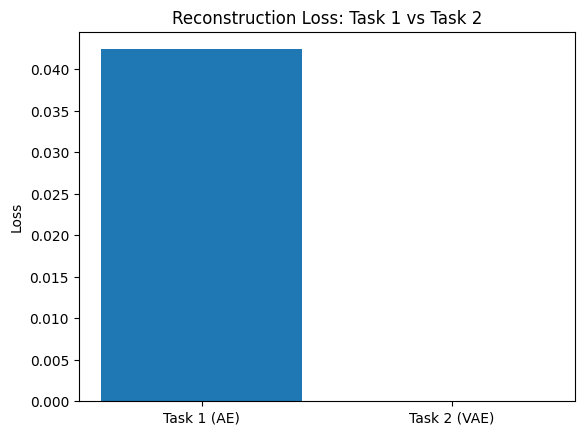

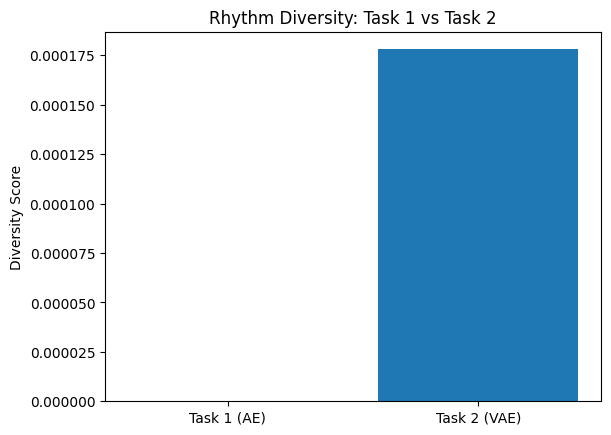

===== TASK 1 vs TASK 2 SUMMARY =====
Task 1 Loss: 0.0424, Rhythm: 3.55e-07
Task 2 Loss: 8.98e-05, Rhythm: 0.000178

Conclusion: Task 2 (VAE) clearly improves both loss and diversity over Task 1 (Autoencoder).


In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# YOUR RESULTS
# -----------------------------

task1_loss = 0.0424
task2_loss = 8.98e-05

task1_rhythm = 3.55e-07
task2_rhythm = 1.78e-04

models = ["Task 1 (AE)", "Task 2 (VAE)"]

# -----------------------------
# LOSS COMPARISON
# -----------------------------
plt.figure()
plt.bar(models, [task1_loss, task2_loss])
plt.title("Reconstruction Loss: Task 1 vs Task 2")
plt.ylabel("Loss")
plt.show()

# -----------------------------
# RHYTHM DIVERSITY COMPARISON
# -----------------------------
plt.figure()
plt.bar(models, [task1_rhythm, task2_rhythm])
plt.title("Rhythm Diversity: Task 1 vs Task 2")
plt.ylabel("Diversity Score")
plt.show()

# -----------------------------
# PRINT SUMMARY (REPORT READY)
# -----------------------------
print("===== TASK 1 vs TASK 2 SUMMARY =====")
print(f"Task 1 Loss: {task1_loss}, Rhythm: {task1_rhythm}")
print(f"Task 2 Loss: {task2_loss}, Rhythm: {task2_rhythm}")
print("\nConclusion: Task 2 (VAE) clearly improves both loss and diversity over Task 1 (Autoencoder).")